# Домашнее задание. Урок 25. Библиотека MatplotLib

Данные выгружены из учебной базы dvdrental в формате CSV и лежат в подпапке `data`.

По условию задания все графики построены **только средствами matplotlib**, без seaborn.

Строятся четыре графика:

1. столбчатая диаграмма — выручка по категориям фильмов;
2. гистограмма — распределение суммы платежей на одного клиента;
3. точечная диаграмма — длительность фильма и принесённая им выручка;
4. тепловая карта — количество фильмов по категориям и возрастным рейтингам.

К каждому графику приведены выводы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

print("pandas    :", pd.__version__)
print("matplotlib:", matplotlib.__version__)

pandas    : 3.0.3
matplotlib: 3.11.0


## Загрузка и подготовка данных

In [2]:
film          = pd.read_csv("data/film.csv")
film_category = pd.read_csv("data/film_category.csv")
category      = pd.read_csv("data/category.csv")
inventory     = pd.read_csv("data/inventory.csv")
rental        = pd.read_csv("data/rental.csv")
payment       = pd.read_csv("data/payment.csv")

for name, df in [("film", film), ("film_category", film_category), ("category", category),
                 ("inventory", inventory), ("rental", rental), ("payment", payment)]:
    print(f"{name:14} строк: {df.shape[0]:6}")

film           строк:   1000
film_category  строк:   1000
category       строк:     16
inventory      строк:   4581
rental         строк:  16044
payment        строк:  14596


In [3]:
# Собираем цепочку «платёж -> прокат -> экземпляр -> фильм -> категория».
# Она понадобится сразу нескольким графикам, поэтому считаем её один раз.
film_money = (
    payment[["payment_id", "rental_id", "amount"]]
    .merge(rental[["rental_id", "inventory_id"]], on="rental_id", how="inner")
    .merge(inventory[["inventory_id", "film_id"]], on="inventory_id", how="inner")
    .merge(film[["film_id", "title", "length", "rating", "rental_rate"]],
           on="film_id", how="inner")
    .merge(film_category[["film_id", "category_id"]], on="film_id", how="inner")
    .merge(category[["category_id", "name"]], on="category_id", how="inner")
    .rename(columns={"name": "category"})
)

print("Строк в объединённой таблице:", film_money.shape[0])
film_money.head()

Строк в объединённой таблице: 14596


,payment_id,rental_id,amount,inventory_id,film_id,title,length,rating,rental_rate,category_id,category
0,17503,1520,7.99,3419,749,Rules Human,153,R,4.99,11,Horror
1,17504,1778,1.99,2512,552,Majestic Floats,130,PG,0.99,6,Documentary
2,17505,1849,7.99,2507,551,Maiden Home,138,PG,4.99,13,New
3,17506,2829,2.99,2047,445,Hyde Doctor,100,G,2.99,4,Classics
4,17507,3130,7.99,2569,563,Massacre Usual,165,R,4.99,10,Games


## График 1. Столбчатая диаграмма — выручка по категориям фильмов

Столбчатая диаграмма подходит, когда нужно сравнить значение одного числового
показателя между несколькими категориями. Здесь это выручка по 16 жанрам.

In [4]:
revenue_by_category = (
    film_money
    .groupby("category", as_index=False)
    .agg(revenue=("amount", "sum"))
    .sort_values("revenue", ascending=False)
)

revenue_by_category

,category,revenue
14,Sports,4892.19
13,Sci-Fi,4336.01
1,Animation,4245.31
6,Drama,4118.46
4,Comedy,4002.48
12,New,3966.38
0,Action,3951.84
8,Foreign,3934.47
9,Games,3922.18
7,Family,3830.15


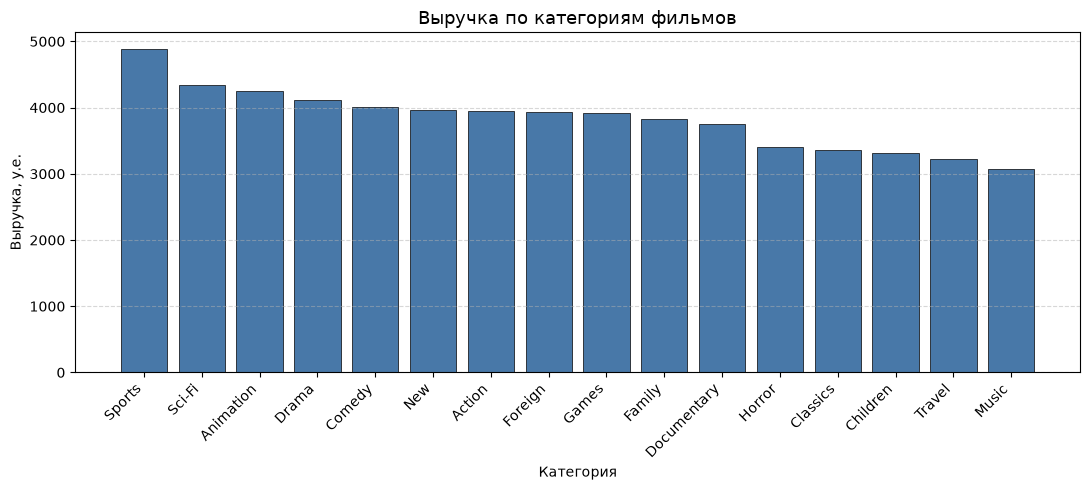

In [5]:
plt.figure(figsize=(11, 5))

plt.bar(revenue_by_category["category"],
        revenue_by_category["revenue"],
        color="#4878a8",
        edgecolor="black",
        linewidth=0.5)

plt.title("Выручка по категориям фильмов", fontsize=13)
plt.xlabel("Категория")
plt.ylabel("Выручка, у.е.")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Выводы по графику 1

Разброс между жанрами оказался небольшим. Лидер приносит примерно в 1,6 раза
больше аутсайдера, и это при шестнадцати жанрах. Ни одна категория
не является определяющей для выручки.

Практический смысл этого наблюдения обратный тому, что обычно ищут в таком графике.
Раз выручка распределена по жанрам почти равномерно, вывод «нужно закупать
только лидирующие категории» был бы ошибкой: отказ от нижних жанров отрезал бы
заметную долю выручки, не дав ничего взамен.

Разницу между соседними столбцами стоит считать шумом. Значимо здесь только
сравнение самых верхних категорий с самыми нижними.

## График 2. Гистограмма — распределение суммы платежей на клиента

Гистограмма показывает не отдельные значения, а форму распределения: где
сосредоточена основная масса наблюдений и насколько они разбросаны.

In [6]:
customer_total = (
    payment
    .groupby("customer_id", as_index=False)
    .agg(total_amount=("amount", "sum"))
)

customer_total["total_amount"] = customer_total["total_amount"].round(2)

print("Клиентов:", customer_total.shape[0])
print(customer_total["total_amount"].describe().round(2))

Клиентов: 599
count    599.00
mean     102.36
std       25.23
min       27.93
25%       85.77
50%       99.74
75%      117.24
max      211.55
Name: total_amount, dtype: float64


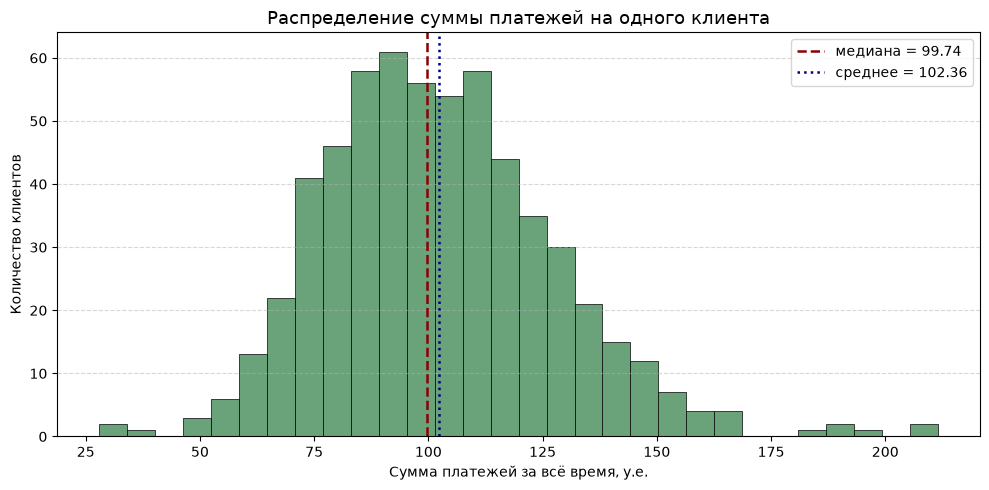

In [7]:
median_value = customer_total["total_amount"].median()
mean_value = customer_total["total_amount"].mean()

plt.figure(figsize=(10, 5))

plt.hist(customer_total["total_amount"],
         bins=30,
         color="#6aa37a",
         edgecolor="black",
         linewidth=0.5)

plt.axvline(median_value, color="darkred", linestyle="--", linewidth=1.8,
            label=f"медиана = {median_value:.2f}")
plt.axvline(mean_value, color="navy", linestyle=":", linewidth=1.8,
            label=f"среднее = {mean_value:.2f}")

plt.title("Распределение суммы платежей на одного клиента", fontsize=13)
plt.xlabel("Сумма платежей за всё время, у.е.")
plt.ylabel("Количество клиентов")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Выводы по графику 2

Распределение одновершинное и близко к симметричному: основная масса клиентов
сосредоточена в середине диапазона, а крайние значения встречаются редко.
Среднее и медиана расположены рядом — это прямое следствие симметричности.

Для клиентских данных такая картина нетипична. Обычно выручка распределена
с сильным правым хвостом, когда небольшая группа клиентов приносит
непропорционально много. Здесь такого хвоста нет, и это говорит скорее
об искусственном происхождении учебных данных, чем о свойствах реального бизнеса.

Практический вывод из формы распределения: раз выраженной группы «крупных
клиентов» не существует, сегментация по сумме платежей даст условные границы.
Любой порог здесь разрежет плотную середину распределения, а не отделит
естественно обособленную группу.

## График 3. Точечная диаграмма — длительность фильма и его выручка

Точечная диаграмма нужна, чтобы увидеть связь между двумя числовыми величинами.
Проверяется предположение, что более длинные фильмы приносят больше денег.

In [8]:
film_stats = (
    film_money
    .groupby(["film_id", "title"], as_index=False)
    .agg(revenue=("amount", "sum"),
         rentals=("payment_id", "count"))
    .merge(film[["film_id", "length"]], on="film_id", how="inner")
)

film_stats["revenue"] = film_stats["revenue"].round(2)

print("Фильмов с прокатами:", film_stats.shape[0])
film_stats.head()

Фильмов с прокатами: 958


,film_id,title,revenue,rentals,length
0,1,Academy Dinosaur,33.79,21,86
1,2,Ace Goldfinger,52.93,7,48
2,3,Adaptation Holes,34.89,11,50
3,4,Affair Prejudice,83.79,21,117
4,5,African Egg,47.89,11,130


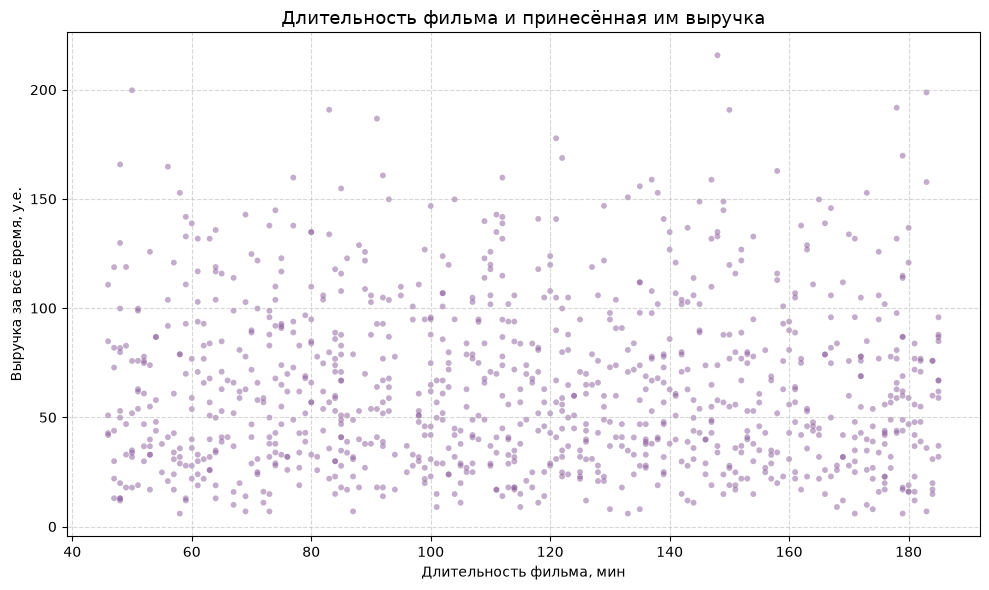

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(film_stats["length"],
            film_stats["revenue"],
            s=18,
            alpha=0.5,
            color="#8a5a9a",
            edgecolors="none")

plt.title("Длительность фильма и принесённая им выручка", fontsize=13)
plt.xlabel("Длительность фильма, мин")
plt.ylabel("Выручка за всё время, у.е.")
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# Численная проверка того, что видно на глаз
corr = film_stats["length"].corr(film_stats["revenue"])
print(f"Коэффициент корреляции длительности и выручки: {corr:.3f}")

Коэффициент корреляции длительности и выручки: -0.008


### Выводы по графику 3

Облако точек не имеет направления: при любой длительности встречаются фильмы
и с высокой, и с низкой выручкой. Коэффициент корреляции близок к нулю,
что подтверждает увиденное на глаз.

Вывод: длительность фильма не объясняет его выручку. Гипотеза, с которой
строился график, не подтвердилась — и это полноценный результат. Если бы
требовалось предсказывать выручку фильма, поле `length` в качестве признака
брать не стоило бы.

Бросается в глаза и другое: точки выстроились в горизонтальные полосы.
Причина в том, что выручка складывается из платежей фиксированного размера,
поэтому суммы у разных фильмов часто совпадают. Это особенность данных,
а не связь между переменными.

## График 4. Тепловая карта — категория и возрастной рейтинг

Тепловая карта показывает, как распределены объекты по сочетаниям двух
категориальных признаков. Здесь это жанр фильма и его возрастной рейтинг.

Матрица значений собирается сводной таблицей, а рисуется методом `imshow`,
который выводит двумерный массив как изображение, раскрашивая ячейки
по величине значения.

In [11]:
films_with_category = (
    film[["film_id", "rating"]]
    .merge(film_category[["film_id", "category_id"]], on="film_id", how="inner")
    .merge(category[["category_id", "name"]], on="category_id", how="inner")
    .rename(columns={"name": "category"})
)

matrix = pd.pivot_table(
    films_with_category,
    index="category",
    columns="rating",
    values="film_id",
    aggfunc="count",
    fill_value=0,
)

# приводим рейтинги к возрастающему порядку строгости
rating_order = ["G", "PG", "PG-13", "R", "NC-17"]
matrix = matrix[rating_order]

matrix

rating,G,PG,PG-13,R,NC-17
category,,,,,
Action,18,9,11,14,12
Animation,13,11,19,8,15
Children,10,15,14,9,12
Classics,11,10,13,14,9
Comedy,11,16,12,8,11
Documentary,14,16,12,13,13
Drama,12,7,22,6,15
Family,10,18,11,16,14
Foreign,13,14,19,15,12


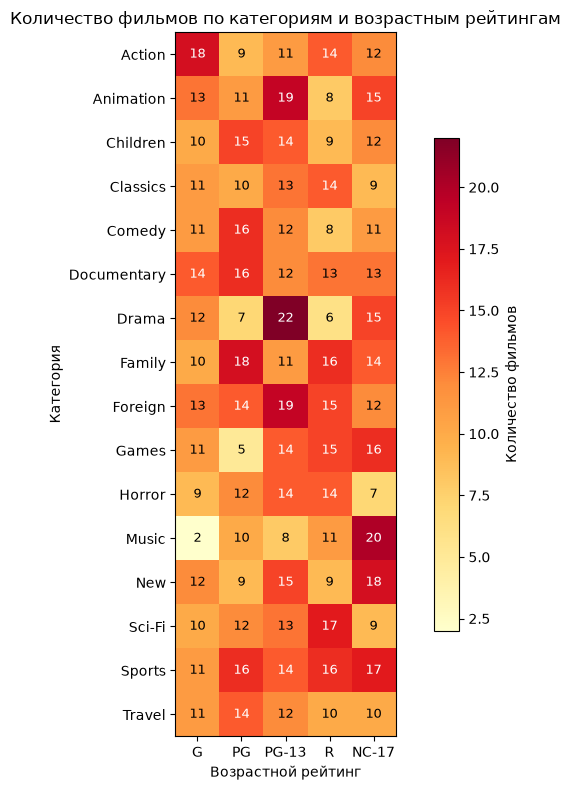

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(matrix.values, cmap="YlOrRd")

ax.set_xticks(np.arange(len(matrix.columns)))
ax.set_xticklabels(matrix.columns)
ax.set_yticks(np.arange(len(matrix.index)))
ax.set_yticklabels(matrix.index)

# подписываем каждую ячейку её значением, иначе карту трудно читать точно
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.values[i, j]
        ax.text(j, i, value, ha="center", va="center",
                color="black" if value < matrix.values.max() * 0.6 else "white",
                fontsize=9)

ax.set_title("Количество фильмов по категориям и возрастным рейтингам", fontsize=12)
ax.set_xlabel("Возрастной рейтинг")
ax.set_ylabel("Категория")
fig.colorbar(im, ax=ax, shrink=0.7, label="Количество фильмов")
plt.tight_layout()
plt.show()

In [13]:
# Проверим, есть ли перекос: сколько фильмов приходится на каждый рейтинг
print(matrix.sum(axis=0).sort_values(ascending=False))
print()
print("Всего фильмов в матрице:", matrix.values.sum())

rating
PG-13    223
NC-17    210
R        195
PG       194
G        178
dtype: int64

Всего фильмов в матрице: 1000


In [14]:
# Отличается ли разброс по ячейкам от случайного?
values = matrix.values
cells = values.size

print("Ячеек в матрице       :", cells)
print("Минимум в ячейке      :", values.min())
print("Максимум в ячейке     :", values.max())
print("Среднее на ячейку     :", round(values.mean(), 2))
print("Стандартное отклонение:", round(values.std(), 2))
print()
# при чисто случайном разбросе счётчиков отклонение близко к корню из среднего
print("Корень из среднего    :", round(np.sqrt(values.mean()), 2))

Ячеек в матрице       : 80
Минимум в ячейке      : 2
Максимум в ячейке     : 22
Среднее на ячейку     : 12.5
Стандартное отклонение: 3.51

Корень из среднего    : 3.54


### Выводы по графику 4

Отдельные ячейки заметно различаются: от 2 фильмов в сочетании «Music и G»
до 22 в сочетании «Drama и PG-13». На первый взгляд это похоже на структуру,
но прежде чем её интерпретировать, стоит проверить, отличается ли разброс
от случайного.

Тысяча фильмов распределена по 80 ячейкам, то есть в среднем по 12,5 на ячейку.
Фактическое стандартное отклонение по ячейкам равно 3,5 — ровно столько
и ожидается при чисто случайном распределении такого количества объектов.
Значит, различия между ячейками объясняются случайностью, а не связью
между жанром и рейтингом.

Суммы по рейтингам это подтверждают: от 178 до 223 фильмов на каждый
из пяти рейтингов, то есть перекоса нет и в целом по каталогу.

Для реального каталога такая картина невозможна. Ожидалось бы, что в детских
жанрах преобладают мягкие рейтинги, а во взрослых — строгие. Здесь же
в категории Children числится 12 фильмов с рейтингом NC-17, то есть
«детских фильмов для взрослых». Это прямое указание на то, что рейтинги
в учебной базе проставлены случайно.

Практический вывод для аналитика: увидев на тепловой карте яркую ячейку,
нельзя сразу считать её находкой. Сначала нужно понять, какой разброс
дала бы простая случайность при таком объёме данных.

Отдельно стоит отметить приём с подписью значений внутри ячеек. Без него
тепловая карта позволяет сравнивать ячейки только на глаз по оттенку,
а при близких значениях, как здесь, оттенки почти неразличимы. Цвет показывает
общую картину, подписи дают точность.

## Общий вывод по работе

Построены все четыре требуемых типа графиков средствами matplotlib, к каждому
подобраны переменные, для которых он уместен: столбчатая диаграмма — для
сравнения категорий, гистограмма — для формы распределения, точечная — для
связи двух числовых величин, тепловая карта — для сочетания двух категориальных.

Содержательно три графика из четырёх показали отсутствие ожидаемой структуры:
выручка равномерна по жанрам, длительность не связана с выручкой, жанр
не связан с возрастным рейтингом. Это закономерно для сгенерированной учебной
базы, но важно как методический вывод: график, не показавший зависимости, —
такой же результат, как и график, её показавший. Он избавляет от неверной
гипотезы до того, как на ней будет что-то построено.